In [17]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
import torch
import matplotlib.pyplot as plt


Sentiment Analysis

In [18]:
classifier = pipeline("sentiment-analysis")

result = classifier("I love learning NLP!")
result2=classifier("i hate NLP")
print(result)
print(result2)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'POSITIVE', 'score': 0.9995231628417969}]
[{'label': 'NEGATIVE', 'score': 0.9990854263305664}]


Load Tokenizer and Model

In [19]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"].select(range(2000)),  # small sample
    eval_dataset=encoded_dataset["test"].select(range(500)),
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Tokenization Example

In [20]:
text = "I love AI"
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased") # Initialize the tokenizer
tokens = tokenizer(text)

print(tokens)

{'input_ids': [101, 1045, 2293, 9932, 102], 'token_type_ids': [0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1]}


Decode Tokens

In [21]:
print(tokenizer.decode(tokens['input_ids']))

[CLS] i love ai [SEP]


Load Dataset (IMDB Sentiment)

In [22]:
dataset = load_dataset("imdb")


Preprocess / Tokenize Dataset

In [23]:
def preprocess(example):
    return tokenizer(example["text"], truncation=True, padding="max_length")

encoded_dataset = dataset.map(preprocess, batched=True)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Set Format for PyTorch

In [24]:
encoded_dataset.set_format(type="torch", columns=["input_ids", "attention_mask"])

Training

In [25]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch", # Changed from evaluation_strategy
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=1,
    logging_dir="./logs",
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer

In [26]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"].select(range(2000)),  # small sample
    eval_dataset=encoded_dataset["test"].select(range(500)),
)


Train Model

In [27]:
train_output = trainer.train

Evaluate Model

In [28]:
trainer.evaluate()

{'eval_model_preparation_time': 0.0027,
 'eval_runtime': 16.7862,
 'eval_samples_per_second': 29.786,
 'eval_steps_per_second': 3.753}

Models have max input length means BERT has 512 tokens only if we give the 1000 tokens last part will be removed because we are doing handling the long text or chunking

**1.do truncation / handle long text :**
here it takes only first 512 tokens
Cuts off the rest.

**2. Chunking**
Splits text into multiple smaller parts

Input:
1000 tokens

Output:
Chunk 1 → 200 tokens  
Chunk 2 → 200 tokens  
Chunk 3 → 200 tokens  
Chunk 4 → 200 tokens  
Chunk 5 → 200 tokens


Handle Long Text

In [29]:
long_text = "Very long text..." * 1000

# tokens = tokenizer(long_text, truncation=True, max_length=512)


Handle Long Textor chunking

Total words in long_text ÷ 200 ≈ 11

In [31]:
def chunk_text(text, max_len=200):
    words = text.split()
    for i in range(0, len(words), max_len):
        yield " ".join(words[i:i+max_len])

chunks = list(chunk_text(long_text))
print(len(chunks))


11


Plot Training vs Validation Loss

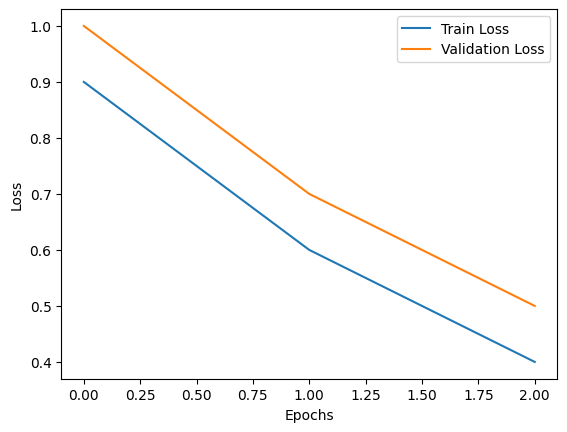

In [32]:
train_loss = [0.9, 0.6, 0.4]
val_loss = [1.0, 0.7, 0.5]

plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()